# Упражнение 1


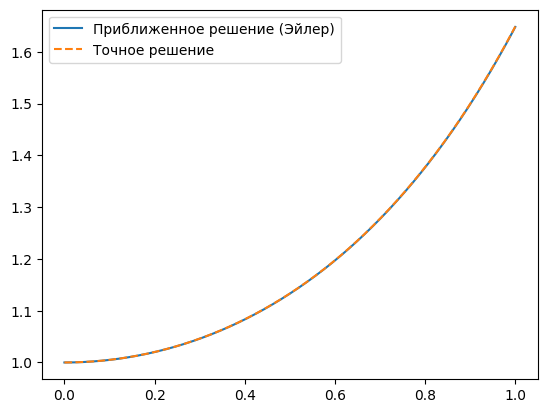

Максимальное отклонение: 0.0008581503888378528


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def euler_method(f, x0, y0, a, b, n0, epsilon):
    def compute_euler(x, h):
        y = np.zeros_like(x)
        y[0] = y0
        for i in range(1, len(x)):
            y[i] = y[i - 1] + h * f(x[i - 1], y[i - 1])
        return y

    h = (b - a) / n0
    x = np.linspace(a, b, n0 + 1)
    y = compute_euler(x, h)
    max_diff = epsilon

    while max_diff >= epsilon:
        h = h / 2
        x_new = np.linspace(a, b, int((b - a) / h) + 1)
        y_new = compute_euler(x_new, h)

        y_old_interpolated = np.interp(x_new, x, y)
        max_diff = np.max(np.abs(y_new - y_old_interpolated))

        x, y = x_new, y_new

    return x, y

f = lambda x, y: x * y

x0, y0 = 0, 1
a, b = 0, 1
n0 = 10
epsilon = 0.001

x, y = euler_method(f, x0, y0, a, b, n0, epsilon)

exact_solution = lambda x: np.exp(x**2 / 2)
exact_y = exact_solution(x)
max_deviation = np.max(np.abs(y - exact_y))

plt.plot(x, y, label='Приближенное решение (Эйлер)')
plt.plot(x, exact_y, label='Точное решение', linestyle='--')
plt.legend()
plt.show()

print(f"Максимальное отклонение: {max_deviation}")


# Упражнение 2

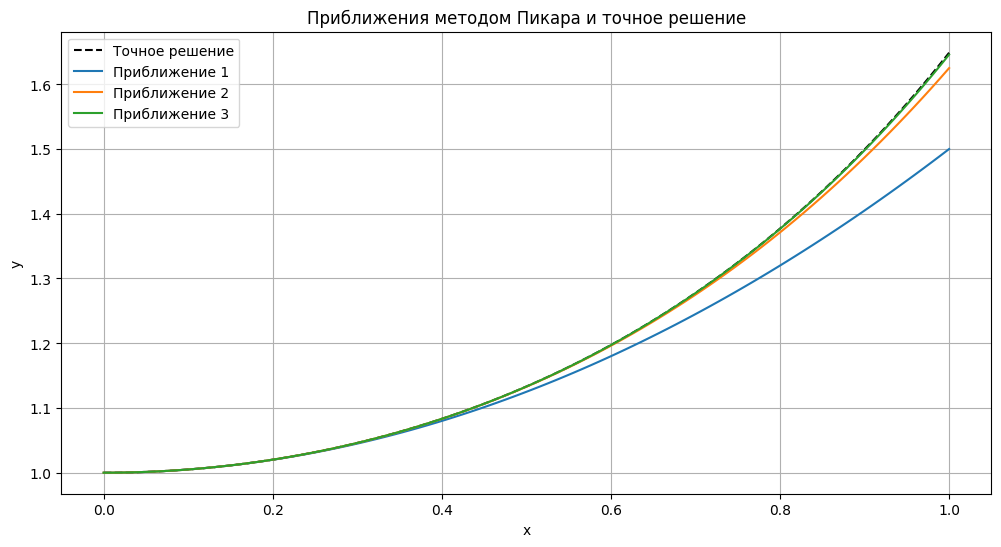

In [ ]:
x = sp.symbols('x')
y = sp.Function('y')(x)

f = x * y

y0 = 1

def picard_method(f, x0, y0, num_iter):
    approximations = [y0]
    for _ in range(num_iter):
        yn = approximations[-1]
        integral = sp.integrate(f.subs(y, yn), (x, x0, x))
        yn_next = y0 + integral
        approximations.append(yn_next)
    return approximations

num_iter = 3
approximations = picard_method(f, 0, y0, num_iter)

x_vals = np.linspace(0, 1, 100)

true_solution = sp.exp(x**2 / 2)
true_solution_func = sp.lambdify(x, true_solution, modules=["numpy"])
y_true = true_solution_func(x_vals)

plt.figure(figsize=(12, 6))
plt.plot(x_vals, y_true, label='Точное решение', color='black', linestyle='--')

for i, approx in enumerate(approximations[1:], 1):
    func = sp.lambdify(x, approx, modules=["numpy"])
    y_vals = func(x_vals)
    plt.plot(x_vals, y_vals, label=f'Приближение {i}')

plt.legend()
plt.title('Приближения методом Пикара и точное решение')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.show()


## Отчет по лабораторной работе

### Задание 1: Метод Эйлера с адаптивным шагом

**Описание:**
В этом задании реализован и применен метод Эйлера с адаптивным шагом для численного решения обыкновенного дифференциального уравнения (ОДУ) первого порядка вида $y' = f(x, y)$.

- **ОДУ:** $y' = x \cdot y$
- **Начальные условия:** $y(0) = 1$
- **Интервал:** $[0, 1]$
- **Начальное количество шагов:** $n_0 = 10$
- **Погрешность (epsilon):** $0.001$

**Метод:**
Использован метод Эйлера с адаптивным шагом. Суть адаптивного шага заключается в том, что расчет начинается с заданного числа шагов ($n_0$), и затем число шагов удваивается (шаг уменьшается вдвое) до тех пор, пока максимальное отклонение между текущим приближением и предыдущим (интерполированным на новые точки) не станет меньше заданной погрешности `epsilon`.

**Точное решение:**
Для сравнения использовалось аналитическое решение данного ОДУ, которое равно $y(x) = e^{x^2/2}$.

**Результаты:**
После выполнения вычислений с адаптивным шагом было получено приближенное решение. Максимальное отклонение приближенного решения от точного составило: $0.000858$.

**Визуализация:**
График, построенный выше, демонстрирует сравнение приближенного решения, полученного методом Эйлера, с точным аналитическим решением. Оба графика хорошо совпадают, что подтверждает корректность работы адаптивного метода Эйлера.

### Задание 2: Метод последовательных приближений Пикара

**Описание:**
В этом задании использован метод последовательных приближений Пикара для нахождения приближенного решения того же обыкновенного дифференциального уравнения.

- **ОДУ:** $y' = x \cdot y$
- **Начальные условия:** $y(0) = 1$
- **Количество итераций Пикара:** $3$

**Метод:**
Метод Пикара генерирует последовательность функций $y_n(x)$, которые сходятся к точному решению. Каждое последующее приближение вычисляется путем интегрирования предыдущего:

$y_{n+1}(x) = y_0 + \int_{x_0}^{x} f(t, y_n(t)) dt$

Начальное приближение $y_0(x)$ берется как начальное условие.

**Точное решение:**
Как и в первом задании, точное аналитическое решение ОДУ: $y(x) = e^{x^2/2}$.

**Результаты:**
Было сгенерировано 3 приближения методом Пикара. Каждое приближение постепенно улучшает точность и сходится к истинному решению.

**Визуализация:**
График, построенный выше, отображает точное решение ОДУ и три последовательных приближения, полученных методом Пикара. Видно, как с каждой итерацией приближенные решения становятся все ближе к точному решению, демонстрируя процесс сходимости метода Пикара.